# Business Understanding

## Project Domain

Domain: Healthcare & Medical Diagnostics
Sub-Domain: Mental Health & Early Screening Systems

Proyek Autism Screening on Adults termasuk dalam domain layanan kesehatan, khususnya pada bidang mental health diagnostics. Sistem ini memanfaatkan data science dan machine learning untuk membantu proses deteksi dini kemungkinan gangguan spektrum autisme (ASD) pada orang dewasa. Dengan pendekatan ini, proses penyaringan dapat dilakukan secara cepat, efisien, dan dapat diakses oleh lebih banyak orang tanpa memerlukan prosedur diagnostik yang panjang. Model ini berfungsi sebagai alat bantu (decision support system) bagi profesional kesehatan dalam memberikan evaluasi awal berbasis data terhadap risiko ASD.

## Problem Statements

Masalah yang Dihadapi:

1. Kurangnya Deteksi Dini pada Orang Dewasa
Banyak orang dewasa dengan autisme yang tidak terdiagnosis karena gejala yang tidak selalu tampak jelas atau dianggap sebagai perilaku umum. Ini menyebabkan keterlambatan dalam intervensi dan dukungan.

2. Keterbatasan Akses ke Diagnosis Profesional
Proses diagnosis autisme biasanya memerlukan evaluasi oleh profesional kesehatan mental yang memakan waktu dan biaya, serta tidak selalu tersedia di daerah terpencil atau negara berkembang.

3. Stigma Sosial terhadap Pemeriksaan Mental
Individu mungkin ragu untuk menjalani pemeriksaan resmi karena takut akan stigma sosial atau diskriminasi akibat hasil diagnosis.

4. Kurangnya Alat Bantu Skrining Otomatis dan Cepat
Saat ini, masih terbatas alat berbasis teknologi yang mampu membantu proses skrining secara cepat dan mandiri, sehingga banyak kasus yang terlewatkan.

## Goals

Membangun sistem berbasis AI (Artificial Neural Network) yang mampu memprediksi kemungkinan seseorang mengalami Autism Spectrum Disorder (ASD) berdasarkan parameter berikut:

- Skor Kuesioner ASD (A1–A10): Jawaban atas serangkaian pertanyaan terkait gejala dan perilaku terkait autisme.

- Demografi dan Riwayat Pribadi: Usia, jenis kelamin, etnis, kewarganegaraan, relasi pengisi formulir.

- Faktor Medis dan Riwayat Kesehatan: Riwayat penyakit kuning, riwayat ASD dalam keluarga.

- Pemanfaatan Teknologi: Penggunaan aplikasi skrining ASD sebelumnya.

- Hasil Tes Final: Nilai hasil tes akhir (score result).

Tujuan dari sistem ini adalah untuk:

- Membantu tenaga medis, keluarga, atau individu melakukan deteksi awal terhadap gejala ASD.

- Menyediakan alat skrining otomatis dan efisien berbasis data science dan machine learning.

- Memperluas akses deteksi dini ASD, terutama di wilayah yang kekurangan profesional di bidang psikologi atau neurologi.

## Solution Statements

- Model Machine Learning dengan Artificial Neural Network (ANN)
Membangun model klasifikasi berbasis Artificial Neural Network untuk memprediksi kemungkinan seseorang mengalami ASD. Model dilatih menggunakan data kuesioner, demografi, dan hasil tes dengan target akurasi tinggi (>90%).

- Aplikasi Web Interaktif (Streamlit)
Mengembangkan aplikasi web berbasis Streamlit untuk menyediakan antarmuka yang ramah pengguna. Pengguna dapat memasukkan data seperti skor kuesioner, usia, jenis kelamin, dan riwayat kesehatan untuk mendapatkan hasil prediksi secara instan.

- Optimasi dengan TensorFlow Lite (TFLite)
Model ANN dikonversi ke format TensorFlow Lite agar dapat dijalankan dengan efisien di perangkat dengan sumber daya terbatas, seperti smartphone atau komputer low-end. Hal ini memungkinkan skrining ASD dilakukan secara portabel dan luas.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"dwirama21","key":"2e49dcc7cf403e23ebf9a32a44f7d021"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d andrewmvd/autism-screening-on-adults

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/autism-screening-on-adults
License(s): other


In [4]:
!mkdir autism-screening-on-adults
!unzip autism-screening-on-adults.zip -d autism-screening-on-adults
!ls autism-screening-on-adults

Archive:  autism-screening-on-adults.zip
  inflating: autism-screening-on-adults/autism_screening.csv  
autism_screening.csv


## Import Library yang dibutuhkan

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf

from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import plot_model

## Exploratory Data Analysis

In [45]:
df = pd.read_csv('/content/autism-screening-on-adults.zip')

In [46]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

In [48]:
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
22.0,37
23.0,37
19.0,35
24.0,34
18.0,31
27.0,31
30.0,30


<Axes: ylabel='age'>

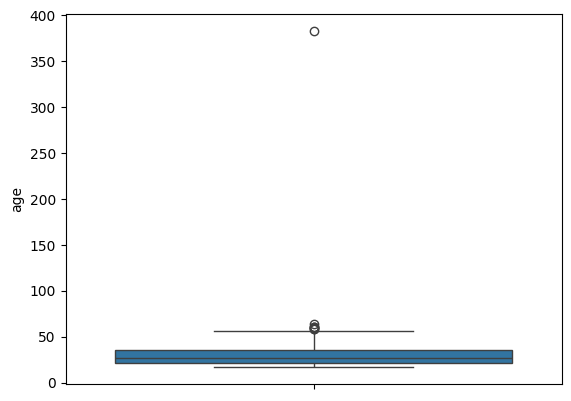

In [49]:
sns.boxplot(df['age'])

In [50]:
df = df.drop(df[df['age'] == 383].index)

In [51]:
df['age'].value_counts()

,count
age,
21.0,49
20.0,46
23.0,37
22.0,37
19.0,35
24.0,34
27.0,31
18.0,31
30.0,30


<Axes: ylabel='age'>

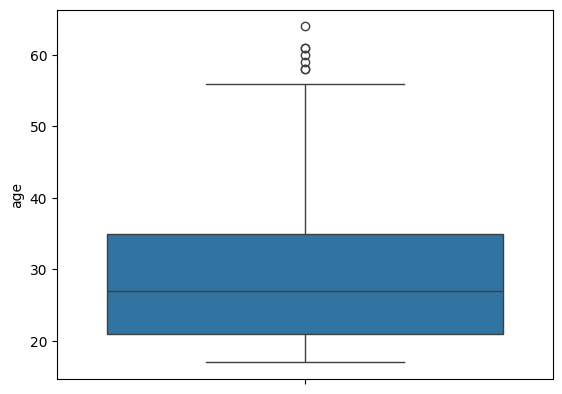

In [52]:
sns.boxplot(df['age'])

In [53]:
df['age'].isnull().sum()

np.int64(2)

In [54]:
df['age'] = df['age'].fillna(round(df['age'].mean()))

In [55]:
df['age'].isnull().sum()

np.int64(0)

In [56]:
df['gender'].value_counts()

,count
gender,
m,367
f,336


In [57]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Asian,123
?,95
Middle Eastern,92
Black,43
South Asian,36
Others,30
Latino,20
Hispanic,13


In [58]:
df['ethnicity'] = df['ethnicity'].replace('?', 'others')

In [59]:
df['ethnicity'].value_counts()

,count
ethnicity,
White-European,233
Asian,123
others,96
Middle Eastern,92
Black,43
South Asian,36
Others,30
Latino,20
Hispanic,13


In [60]:
df['jundice'].value_counts()

,count
jundice,
no,634
yes,69


In [61]:
df['austim'].value_counts()

,count
austim,
no,612
yes,91


In [62]:
df['contry_of_res'].value_counts()

,count
contry_of_res,
United States,113
United Arab Emirates,82
India,81
New Zealand,80
United Kingdom,77
...,...
Angola,1
Azerbaijan,1
Iraq,1


In [63]:
df['used_app_before'].value_counts()

,count
used_app_before,
no,691
yes,12


In [64]:
df['age_desc'].value_counts()

,count
age_desc,
18 and more,703


In [65]:
df['relation'].value_counts()

,count
relation,
Self,521
?,95
Parent,50
Relative,28
Others,5
Health care professional,4


In [66]:
df['relation'] = df['relation'].replace('?', 'Others')
df['relation'].value_counts()

,count
relation,
Self,521
Others,100
Parent,50
Relative,28
Health care professional,4


In [67]:
df['Class/ASD'].value_counts()

,count
Class/ASD,
NO,514
YES,189


In [68]:
#using plotly to visualize the number of autistic and non-autistic patients
fig = px.histogram(df, x='Class/ASD')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [69]:
#using plotly to visualize the average age of autistic and non-autistic patients
fig = px.bar(df.groupby('Class/ASD', as_index=False).agg({'age':'mean'}),
             x='Class/ASD',
             y='age',
             color='Class/ASD',
             title='Average Age of Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Average Age of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [70]:
#using plotly to visualize the count of the gender
fig = px.histogram(df, x='gender')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females </b>', title_x=0.5)

# Show the plot
fig.show()

In [71]:
#using plotly to visualize the count of the males and females for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'gender']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='gender',
             title='Count of Males and Females of Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of Males and Females of Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [72]:
# Count of Autistic Patients in Different Countries
filtered_df = df[df['Class/ASD'] == "YES"]

# Create a histogram
fig = px.histogram(filtered_df, x='contry_of_res')

# Update layout to center the title and set the category order
fig.update_layout(
    title_text='<b>Count of Autistic Patients in Different Countries</b>',
    title_x=0.5,
    xaxis=dict(categoryorder='total descending')
)

# Show the plot
fig.show()

In [73]:
#using plotly to visualize the count of age_desc for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'age_desc']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='age_desc',
             title='Count of People over 18 for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People over 18 for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [74]:
#using plotly to visualize 'jundice' with pie chart
fig = px.pie(df, names='jundice')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People with Jaundice</b>', title_x=0.5)

# Show the plot
fig.show()

In [75]:
#using plotly to visualize the count of people with jundice for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'jundice']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='jundice',
             title='Count of people with jundice for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of people with jundice for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

In [76]:
#using plotly to visualize 'used_app_before' with pie chart
fig = px.pie(df, names='used_app_before')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before</b>', title_x=0.5)

# Show the plot
fig.show()

In [77]:
#using plotly to visualize used_app_before for autistic and non-autistic patients
fig = px.bar(df.groupby(['Class/ASD', 'used_app_before']).size().reset_index(name='count'),
             x='Class/ASD',
             y='count',
             color='used_app_before',
             title='Count of People who used the screening App before for Autistic and Non-Autistic Patients')

# Update layout to center the title
fig.update_layout(title_text='<b>Count of People who used the screening App before for Autistic and Non-Autistic Patients</b>', title_x=0.5)

# Show the plot
fig.show()

# Data Preparation

In [78]:
df = df.drop('age_desc', axis=1)

In [79]:
X = df.drop('Class/ASD', axis=1)
y = df['Class/ASD']

In [80]:
# Columns to apply label encoding
cols_to_encode = ['gender', 'ethnicity', 'jundice', 'austim', 'contry_of_res', 'used_app_before', 'relation']

# Apply label encoding to X
label_encoder_X = LabelEncoder()
for col in cols_to_encode:
    X[col] = label_encoder_X.fit_transform(X[col])

# Apply label encoding to y
label_encoder_y = LabelEncoder()
y = label_encoder_y.fit_transform(y)

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
print(f"Shape of X_train is: {X_train.shape}")
print(f"Shape of Y_train is: {y_train.shape}\n")
print(f"Shape of X_test is: {X_test.shape}")
print(f"Shape of Y_test is: {y_test.shape}")

Shape of X_train is: (562, 19)
Shape of Y_train is: (562,)

Shape of X_test is: (141, 19)
Shape of Y_test is: (141,)


# Modeling

In [83]:
model = Sequential([
        Dense(10, activation='relu', input_dim=19),
        Dense(8, activation='relu'),
        Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [84]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [85]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 297 (1.16 KB)

 Trainable params: 297 (1.16 KB)

 Non-trainable params: 0 (0.00 B)

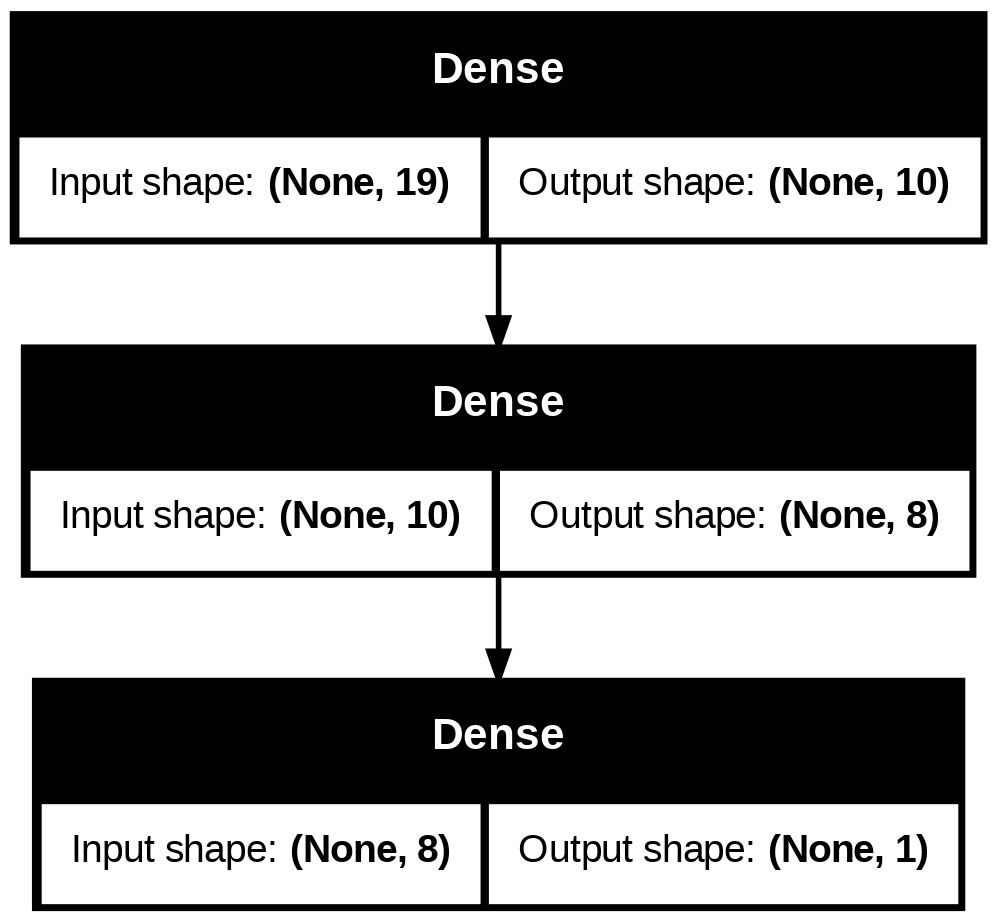

In [86]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [87]:
history = model.fit(X_train, y_train, epochs=150, validation_split=0.25)

Epoch 1/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7031 - loss: 0.6240 - val_accuracy: 0.7518 - val_loss: 0.5593
Epoch 2/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6807 - loss: 0.6376 - val_accuracy: 0.7518 - val_loss: 0.5464
Epoch 3/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6658 - loss: 0.6395 - val_accuracy: 0.7447 - val_loss: 0.5323
Epoch 4/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7205 - loss: 0.6015 - val_accuracy: 0.7447 - val_loss: 0.5280
Epoch 5/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7307 - loss: 0.5632 - val_accuracy: 0.7660 - val_loss: 0.5177
Epoch 6/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7327 - loss: 0.5620 - val_accuracy: 0.7730 - val_loss: 0.5079
Epoch 7/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7676 - loss: 0.5218 - val_accuracy: 0.7660 - val_loss: 0.4988
Epoch 8/150
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7667 - loss: 0.5178 - val_accuracy: 0.7730 - 

# Evaluation

In [88]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"Akurasi Model: {test_accuracy:.4f}")
print(f"Loss Model: {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9263 - loss: 0.2330 
Akurasi Model: 0.9220
Loss Model: 0.2381


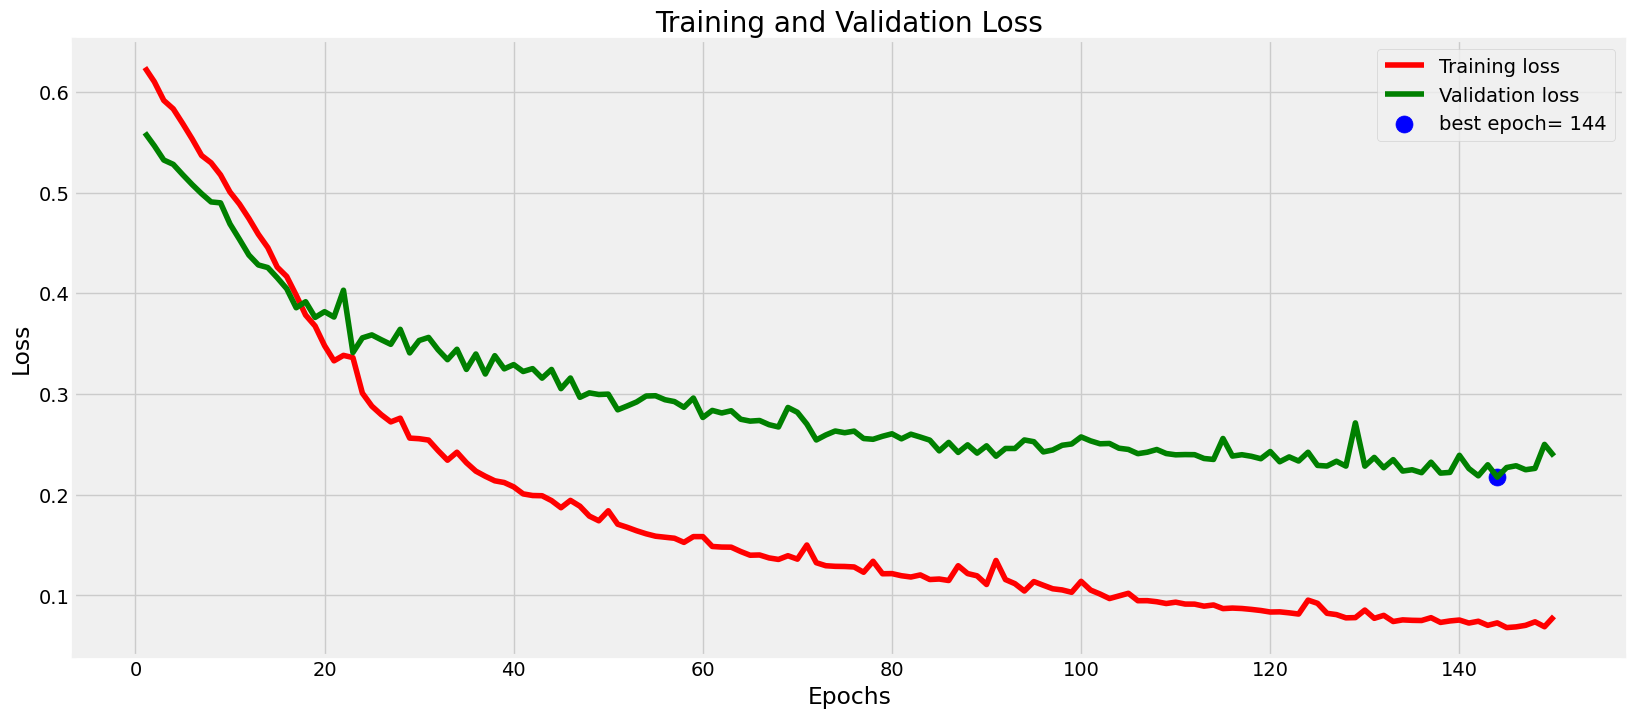

In [89]:
tr_loss = history.history['loss']
val_loss = history.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

Epochs = [i+1 for i in range(len(tr_loss))]
loss_label = f'best epoch= {str(index_loss + 1)}'

# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')

plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

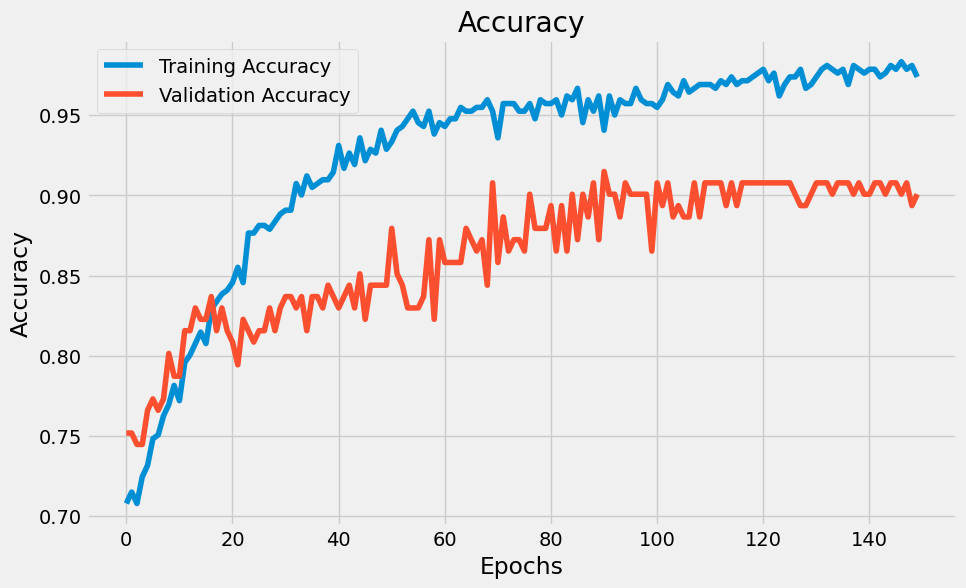

In [90]:
plt.figure(figsize=(10, 6))
plt.plot(history.history["accuracy"], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy')

plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


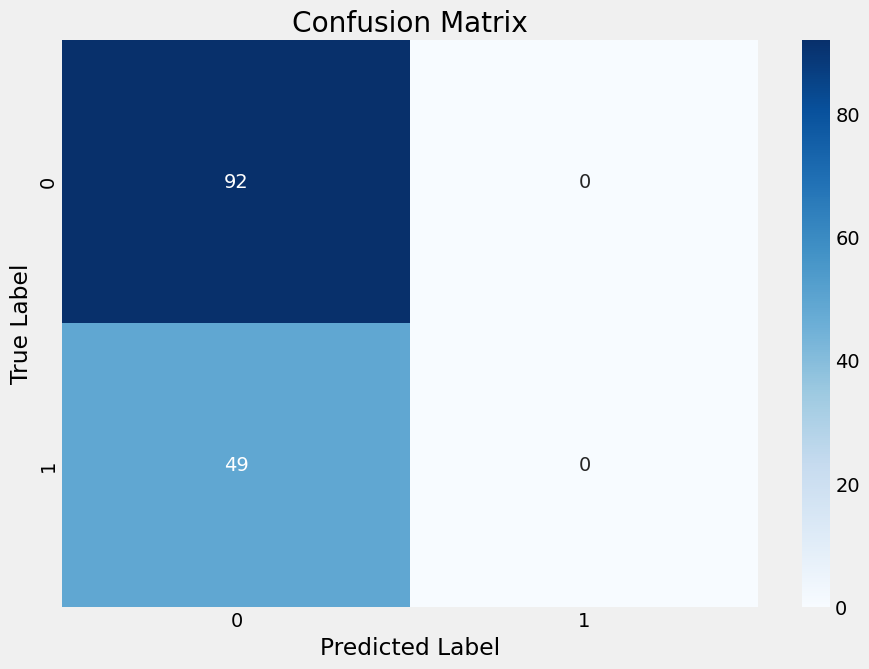

Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        92
           1       0.00      0.00      0.00        49

    accuracy                           0.65       141
   macro avg       0.33      0.50      0.39       141
weighted avg       0.43      0.65      0.52       141



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [91]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes, zero_division='warn'))

# Deployment

## Model Simulation

In [95]:
sample_input = np.array([[25, 1, 4, 1, 1, 10, 1, 1, 3, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1]])
sample_input_df = pd.DataFrame(sample_input, columns=X.columns)

In [96]:
predicted_prob = model.predict(sample_input_df)[0][0]
predicted_class = 1 if predicted_prob >= 0.5 else 0
predicted_label = label_encoder_y.inverse_transform([predicted_class])[0]
print(f"Hasil prediksi: {predicted_label} (probabilitas = {predicted_prob:.2f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Hasil prediksi: YES (probabilitas = 1.00)


## Save Model

In [97]:
# Konversi model ke TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('autism-screening-on-adults.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp1hmk3xdt'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 19), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133497313369488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133497313367952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133497313368912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133497313372560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133497313368528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133497313372752: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [98]:
# Simpan label encoder dan scaler
import joblib
joblib.dump(label_encoder_y, "label_encoder_y.pkl")
label_encoders_X = {}
for col in cols_to_encode:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders_X[col] = le
    joblib.dump(le, f'label_encoder_{col}.pkl')